In [5]:
pip install qiskit qiskit-aer matplotlib pylatexenc

Note: you may need to restart the kernel to use updated packages.


In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit import transpile
import numpy as np

In [8]:
qc = QuantumCircuit(2,2)

In [9]:
qc.h(0)
qc.h(1)

In [10]:
qc.cz(0,1)

In [11]:
qc.h(0)
qc.h(1)

qc.x(0)
qc.x(1)

qc.h(1)
qc.cx(0,1)
qc.h(1)

qc.x(0)
qc.x(1)

qc.h(0)
qc.h(1)

In [12]:
qc.measure([0,1],[0,1])

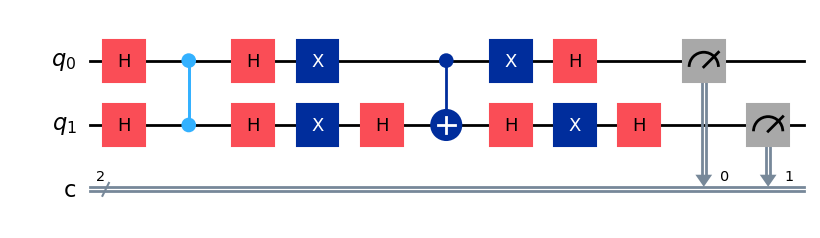

In [13]:
qc.draw('mpl')



Measurement Results:
{'11': 1024}


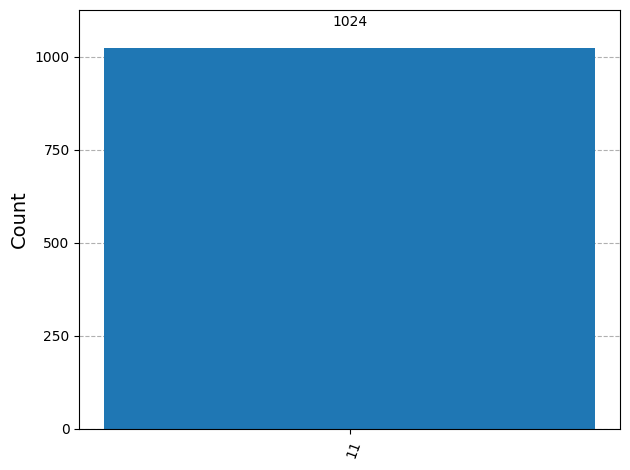

In [14]:
sim = AerSimulator()

compiled = transpile(qc, sim)

result = sim.run(compiled, shots=1024).result()

counts = result.get_counts()

print("Measurement Results:")
print(counts)

plot_histogram(counts)

In [15]:
def classical_search(password, n_bits):
    attempts = 0
    for i in range(2**n_bits):
        guess = format(i, f'0{n_bits}b')
        attempts += 1
        if guess == password:
            break
    return attempts

print("Classical Attempts:", classical_search("11", 2))

Classical Attempts: 4


In [17]:
pip install qiskit-aer

In [18]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt


In [19]:
def oracle(n, marked_state):
    qc = QuantumCircuit(n)

    # Apply X gates for 0 bits
    for i in range(n):
        if marked_state[i] == '0':
            qc.x(i)

    # Multi-controlled Z
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    # Undo X gates
    for i in range(n):
        if marked_state[i] == '0':
            qc.x(i)

    return qc

In [20]:
def diffusion(n):
    qc = QuantumCircuit(n)

    qc.h(range(n))
    qc.x(range(n))

    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    qc.x(range(n))
    qc.h(range(n))

    return qc

In [21]:
def grover_search(n, marked_state):
    qc = QuantumCircuit(n, n)

    # Superposition
    qc.h(range(n))

    # Optimal iterations
    N = 2**n
    r = int(np.floor((np.pi/4) * np.sqrt(N)))

    for _ in range(r):
        qc.append(oracle(n, marked_state), range(n))
        qc.append(diffusion(n), range(n))

    qc.measure(range(n), range(n))

    return qc

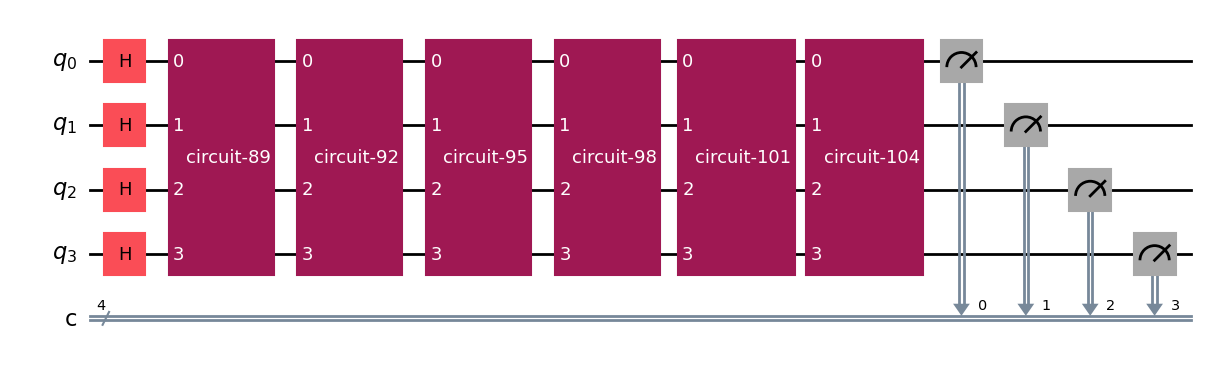

In [43]:
qc.draw('mpl')

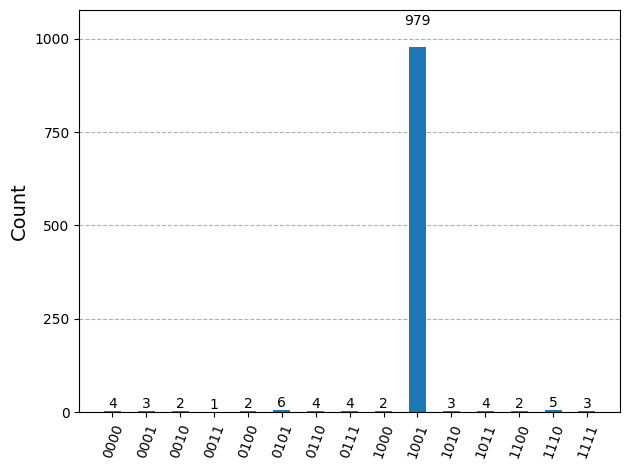

In [22]:
n = 4
marked_state = "1001"

qc = grover_search(n, marked_state)

backend = Aer.get_backend('qasm_simulator')
transpiled = transpile(qc, backend)
result = backend.run(transpiled, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

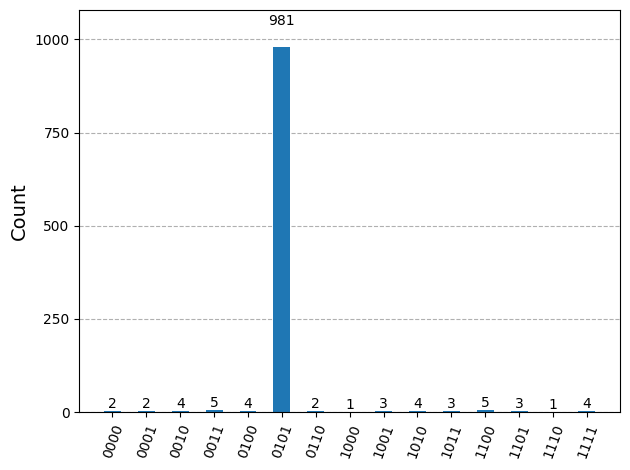

In [23]:
n = 4
marked_state = "1010"

qc = grover_search(n, marked_state)

backend = Aer.get_backend('qasm_simulator')
transpiled = transpile(qc, backend)
result = backend.run(transpiled, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

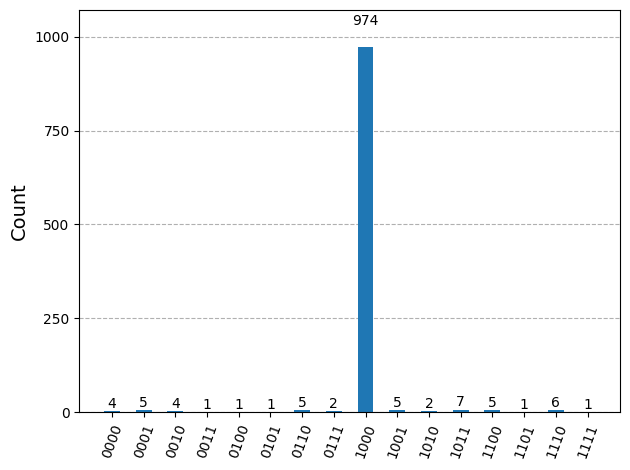

In [24]:
n = 4
marked_state = "0001"

qc = grover_search(n, marked_state)

backend = Aer.get_backend('qasm_simulator')
transpiled = transpile(qc, backend)
result = backend.run(transpiled, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

In [30]:
import numpy as np

def grover_iterations(n_bits):
    N = 2 ** n_bits
    return int(np.floor((np.pi / 4) * np.sqrt(N)))

In [31]:
def classical_search_4bit(password):
    attempts = 0
    for i in range(16):  # 2^4
        guess = format(i, '04b')
        attempts += 1
        if guess == password:
            return attempts

In [40]:
password = "1010"   

n_bits = 4

classical_attempts = classical_search_4bit(password)
quantum_attempts = grover_iterations(n_bits)

print("Password:", password)
print("Classical Attempts:", classical_attempts)
print("Quantum (Grover) attempts:", quantum_attempts)

Password: 1010
Classical Attempts: 11
Quantum (Grover) attempts: 3


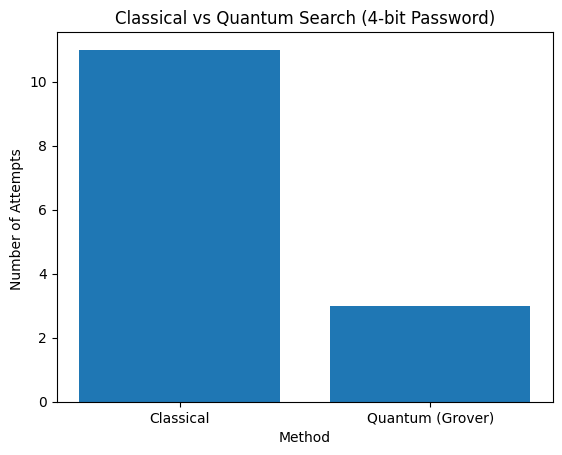

In [39]:
import matplotlib.pyplot as plt

n_bits = 4
password = "1010"

classical_attempts = classical_search_4bit(password)
quantum_attempts = grover_iterations(n_bits)

methods = ["Classical", "Quantum (Grover)"]
attempts = [classical_attempts, quantum_attempts]

plt.figure()
plt.bar(methods, attempts)
plt.xlabel("Method")
plt.ylabel("Number of Attempts ")
plt.title("Classical vs Quantum Search (4-bit Password)")
plt.show()